## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Load Dataset

In [6]:
dataset = pd.read_csv("https://raw.githubusercontent.com/ybifoundation/Dataset/main/Cancer.csv")

In [7]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Dataset Information

In [8]:
dataset.shape

(569, 33)

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
dataset.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Check Missing Values

In [11]:
dataset.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


## Dataset Cleaning

In [12]:
if 'id' in dataset.columns:
    dataset.drop('id',axis=1,inplace=True)

## Diagnosis Count

In [13]:
dataset['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


## Data Visualization

Cancer Count Graph

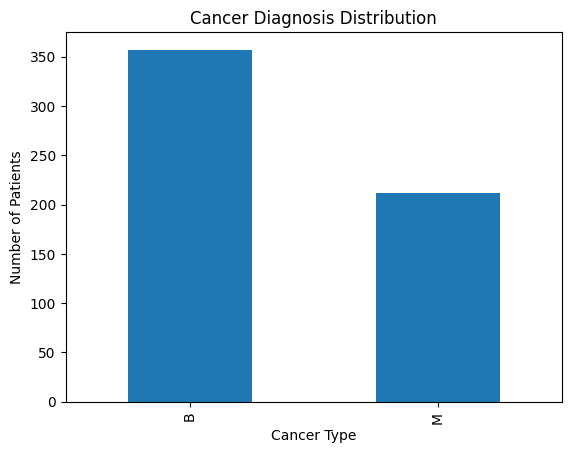

In [14]:
dataset['diagnosis'].value_counts().plot(kind="bar")

plt.xlabel("Cancer Type")
plt.ylabel("Number of Patients")
plt.title("Cancer Diagnosis Distribution")

plt.show()

## Feature Relationship

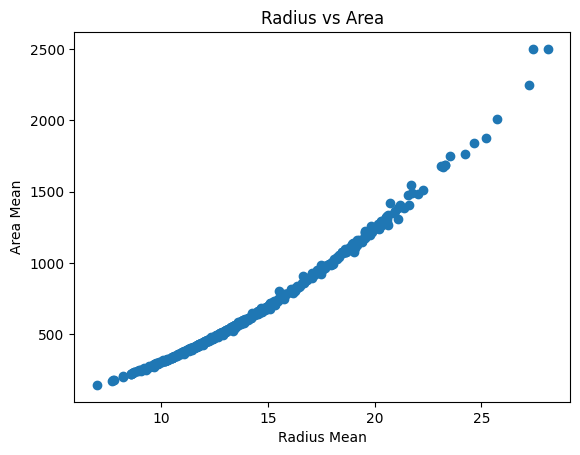

In [15]:
plt.scatter(
dataset['radius_mean'],
dataset['area_mean']
)

plt.xlabel("Radius Mean")
plt.ylabel("Area Mean")

plt.title("Radius vs Area")

plt.show()

## Convert Output Values

In [16]:
dataset['diagnosis']=dataset['diagnosis'].map(
{
'M':1,
'B':0
}
)

## Define Input And Output

In [17]:
X = dataset.drop('diagnosis',axis=1)

y = dataset['diagnosis']

## Train Test Split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

## Feature Scaling

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## Create ML Algorithms

In [29]:
models={

"Logistic Regression":
LogisticRegression(),

"Decision Tree":
DecisionTreeClassifier(),

"Random Forest":
RandomForestClassifier(),

"KNN":
KNeighborsClassifier(),

"SVM":
SVC()

}

## Training And Testing All Models

In [22]:
results=[]
X_train_cleaned = X_train[:, :-1]
X_test_cleaned = X_test[:, :-1]


for name,model in models.items():

    model.fit(X_train_cleaned,y_train)


    prediction=model.predict(X_test_cleaned)


    accuracy=accuracy_score(
    y_test,
    prediction
    )

    precision=precision_score(
    y_test,
    prediction
    )

    recall=recall_score(
    y_test,
    prediction
    )


    f1=f1_score(
    y_test,
    prediction
    )


    results.append(
    [
    name,
    accuracy,
    precision,
    recall,
    f1
    ]
    )


    print("\nAlgorithm:",name)

    print(confusion_matrix(
    y_test,
    prediction
    ))


    print(
    classification_report(
    y_test,
    prediction
    )
    )


Algorithm: Logistic Regression
[[70  1]
 [ 2 41]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Algorithm: Decision Tree
[[67  4]
 [ 4 39]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114


Algorithm: Random Forest
[[70  1]
 [ 3 40]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.

## Performance Comparision Table

In [23]:
comparison = pd.DataFrame(

results,

columns=[
"Algorithm",
"Accuracy",
"Precision",
"Recall",
"F1 Score"
]

)


comparison

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973684,0.976190,0.953488,0.964706
1,Decision Tree,0.929825,0.906977,0.906977,0.906977
2,Random Forest,0.964912,0.975610,0.930233,0.952381
3,KNN,0.947368,0.930233,0.930233,0.930233
4,SVM,0.982456,1.000000,0.953488,0.976190


## Accuracy Comparison Graph

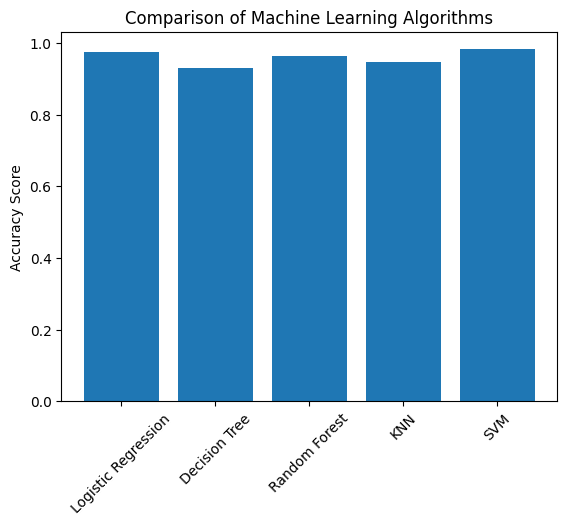

In [24]:
plt.bar(
comparison['Algorithm'],
comparison['Accuracy']
)


plt.xticks(rotation=45)

plt.ylabel("Accuracy Score")

plt.title(
"Comparison of Machine Learning Algorithms"
)

plt.show()

## Select Best Model

In [30]:
best_model = SVC()

best_model.fit(
X_train_cleaned,
y_train
)

SVC()

## Prediction System

In [33]:
sample = X_test_cleaned[0].reshape(1,-1)


result = best_model.predict(sample)


if result[0]==1:

    print("Cancer Type: Malignant")

else:

    print("Cancer Type: Benign")

Cancer Type: Benign
